# Лабораторная работа 2: Метод Ньютона

## Метод Ньютона

### Задание 1. Реализация метода Ньютона

In [76]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, LinAlgError


def armijo_line_search(f, x, d, g, c1=1e-4, rho=0.5, alpha_init=1.0):
    """Backtracking(условие Армихо)."""
    alpha = alpha_init
    f0 = f(x)
    slope = np.dot(g, d)
    while alpha > 1e-16:
        if f(x + alpha * d) <= f0 + c1 * alpha * slope:
            return alpha
        alpha *= rho
    return alpha


def newton_method(f, grad_f, hess_f, x0,
                  alpha_strategy="constant", alpha=1.0,
                  tol=1e-8, max_iter=1000,
                  c1=1e-4, rho=0.5):
    """
    Метод Ньютона для минимизации f(x).

    alpha_strategy: "constant" (фикс. шаг alpha) или "armijo" (подбор шага).
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]

    for _ in range(max_iter):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            g = grad_f(x)
            if not np.all(np.isfinite(g)):
                break
            if np.linalg.norm(g) < tol:
                break

            H = hess_f(x)

            try:
                d = solve(H, -g)
                if not np.all(np.isfinite(d)) or np.dot(g, d) >= 0:
                    d = -g
            except LinAlgError:
                d = -g

        if alpha_strategy == "constant":
            step = alpha
        else:
            step = armijo_line_search(f, x, d, g, c1=c1, rho=rho)

        x = x + step * d
        if not np.all(np.isfinite(x)):
            break
        history.append(x.copy())

    return x, history

print("Метод Ньютона реализован")


Метод Ньютона реализован


### Задание 2. Тест на квадратичной функции

Рассмотрим $f(x) = x^T A x + b^T x$, где:
$$A = \begin{pmatrix} 4 & 1 \\ 1 & 3 \end{pmatrix}, \quad b = \begin{pmatrix} 1 \\ -1 \end{pmatrix}$$

- Градиент: $\nabla f(x) = 2Ax + b$
- Гессе: $\nabla^2 f(x) = 2A$ (константная матрица)

**Теоретическое ожидание:** Для квадратичной функции метод Ньютона сходится ровно за 1 итерацию — аппроксимация Тейлора 2-го порядка точна, и шаг $d = -(2A)^{-1}(2Ax+b)$ сразу приводит в $x^* = -\tfrac{1}{2}A^{-1}b$.

Точный минимум: x* = [-0.18181818  0.22727273]
f(x*) = -0.204545

Начальная точка: [5. 5.]
Найденный минимум: [-0.18181818  0.22727273]
Число итераций: 1
||x_opt - x*|| = 1.15e-15


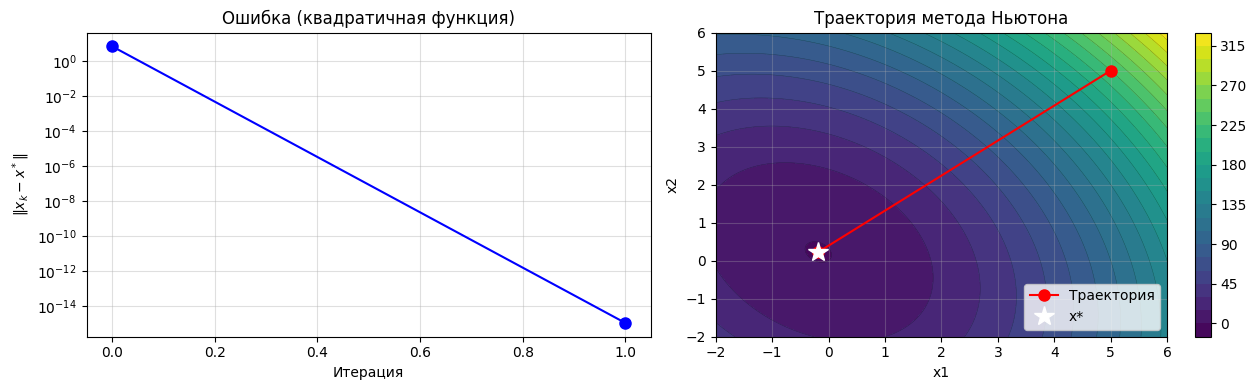

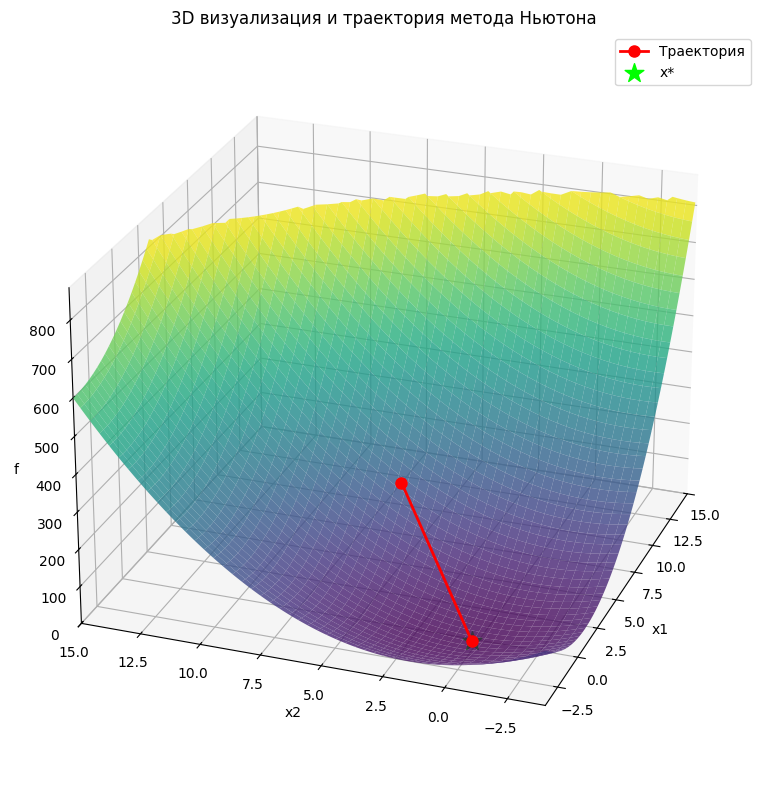


Вывод: метод сходится за 1 итерацию — квадратичная аппроксимация
совпадает с функцией точно, шаг Ньютона сразу попадает в x*.


In [53]:
from mpl_toolkits.mplot3d import Axes3D

A_quad = np.array([[4.0, 1.0],
                   [1.0, 3.0]])
b_quad = np.array([1.0, -1.0])

def f_quad(x):
    return x @ A_quad @ x + b_quad @ x

def grad_quad(x):
    return 2 * A_quad @ x + b_quad

def hess_quad(x):
    return 2 * A_quad

x_star_quad = -0.5 * np.linalg.solve(A_quad, b_quad)
print(f"Точный минимум: x* = {x_star_quad}")
print(f"f(x*) = {f_quad(x_star_quad):.6f}")

x0 = np.array([5.0, 5.0])
x_opt, history = newton_method(f_quad, grad_quad, hess_quad, x0,
                                alpha_strategy="constant", alpha=1.0, tol=1e-12)

print(f"\nНачальная точка: {x0}")
print(f"Найденный минимум: {x_opt}")
print(f"Число итераций: {len(history) - 1}")
print(f"||x_opt - x*|| = {np.linalg.norm(x_opt - x_star_quad):.2e}")

errors = [np.linalg.norm(np.array(h) - x_star_quad) for h in history]
traj = np.array(history)
traj_z = np.array([f_quad(h) for h in history])

xs2d = np.linspace(-2, 6, 200)
ys2d = np.linspace(-2, 6, 200)
Xg2d, Yg2d = np.meshgrid(xs2d, ys2d)
Zg2d = np.array([[f_quad(np.array([xi, yi])) for xi in xs2d] for yi in ys2d])

xs3d = np.linspace(-4, 15, 200)
ys3d = np.linspace(-4, 15, 200)
Xg3d, Yg3d = np.meshgrid(xs3d, ys3d)
Zg3d = np.array([[f_quad(np.array([xi, yi])) for xi in xs3d] for yi in ys3d])
z_clip = np.percentile(Zg3d, 80)
Zg3d_clip = np.where(Zg3d > z_clip, np.nan, Zg3d)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(errors, "b-o", markersize=8)
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel(r"$\|x_k - x^*\|$")
axes[0].set_title("Ошибка (квадратичная функция)")
axes[0].grid(True, alpha=0.4)

cf = axes[1].contourf(Xg2d, Yg2d, Zg2d, levels=25, cmap="viridis")
axes[1].contour(Xg2d, Yg2d, Zg2d, levels=25, colors="k", linewidths=0.3, alpha=0.4)
plt.colorbar(cf, ax=axes[1])
axes[1].plot(traj[:, 0], traj[:, 1], "r-o", markersize=8, label="Траектория", zorder=5)
axes[1].plot(*x_star_quad, "w*", markersize=15, label="x*", zorder=6)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_title("Траектория метода Ньютона")
axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig3d = plt.figure(figsize=(12, 8))
ax3d = fig3d.add_subplot(111, projection="3d")
ax3d.plot_surface(Xg3d, Yg3d, Zg3d_clip, cmap="viridis", alpha=0.80, edgecolor="none")
ax3d.plot(traj[:, 0], traj[:, 1], traj_z,
          "r-o", markersize=8, lw=2, zorder=5, label="Траектория")
ax3d.scatter([x_star_quad[0]], [x_star_quad[1]], [f_quad(x_star_quad)],
             color="lime", s=200, marker="*", zorder=6, label="x*")
ax3d.set_xlim(-4, 15); ax3d.set_ylim(-4, 15); ax3d.set_zlim(bottom=np.nanmin(Zg3d_clip))
ax3d.set_xlabel("x1"); ax3d.set_ylabel("x2"); ax3d.set_zlabel("f")
ax3d.set_title("3D визуализация и траектория метода Ньютона")
ax3d.view_init(elev=25, azim=200)
ax3d.dist = 12
ax3d.legend(); plt.tight_layout(); plt.show()

print("\nВывод: метод сходится за 1 итерацию — квадратичная аппроксимация")
print("совпадает с функцией точно, шаг Ньютона сразу попадает в x*.")


### Задание 3. Функция $f(x,y) = \dfrac{-1}{1 + (x-a)^2 + (y-b)^2}$

- $a$ = среднее гармоническое номеров ИСУ / 100000
- $b$ = среднее геометрическое номеров ИСУ / 100000

Единственный глобальный минимум — $f(a,b) = -1$.

**Аналитика.** При $u = x-a$, $v = y-b$, $D = 1+u^2+v^2$:

$$\nabla f = \frac{2}{D^2}\begin{pmatrix}u\\v\end{pmatrix}, \qquad
H = \frac{2}{D^3}\begin{pmatrix}D-4u^2 & -4uv\\-4uv & D-4v^2\end{pmatrix}$$

Гессе ПО $\Leftrightarrow$ $\lambda_{\min}(H) > 0$ $\Leftrightarrow$
$r = \sqrt{u^2+v^2} < \tfrac{1}{\sqrt{3}} \approx 0.577$.

In [54]:

ISU1 = 489577
ISU2 = 465779

a = (2 * ISU1 * ISU2 / (ISU1 + ISU2)) / 100000   
b = np.sqrt(ISU1 * ISU2) / 100000                  

print(f"ИСУ1={ISU1}, ИСУ2={ISU2}")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Минимум функции: f({a:.4f}, {b:.4f}) = -1")

x_star3 = np.array([a, b])

def f3(xy):
    x, y = xy
    return -1.0 / (1.0 + (x - a)**2 + (y - b)**2)

def grad_f3(xy):
    x, y = xy
    D = 1.0 + (x - a)**2 + (y - b)**2
    return np.array([2*(x-a)/D**2, 2*(y-b)/D**2])

def hess_f3(xy):
    x, y = xy
    u, v = x - a, y - b
    D = 1.0 + u**2 + v**2
    H11 = 2*(D - 4*u**2) / D**3
    H22 = 2*(D - 4*v**2) / D**3
    H12 = -8*u*v / D**3
    return np.array([[H11, H12], [H12, H22]])


ИСУ1=489577, ИСУ2=465779
a = 4.773816
b = 4.775298
Минимум функции: f(4.7738, 4.7753) = -1


#### 3(a). Сходимость с $\alpha=1$, начальные точки вблизи минимума

Аналитическая граница сходимости: r = 1/√7 = 0.3780
Точка 1: r=0.361, итераций=5, ||x_opt-x*||=6.48e-14
Точка 2: r=0.200, итераций=4, ||x_opt-x*||=0.00e+00
Точка 3: r=0.224, итераций=4, ||x_opt-x*||=0.00e+00


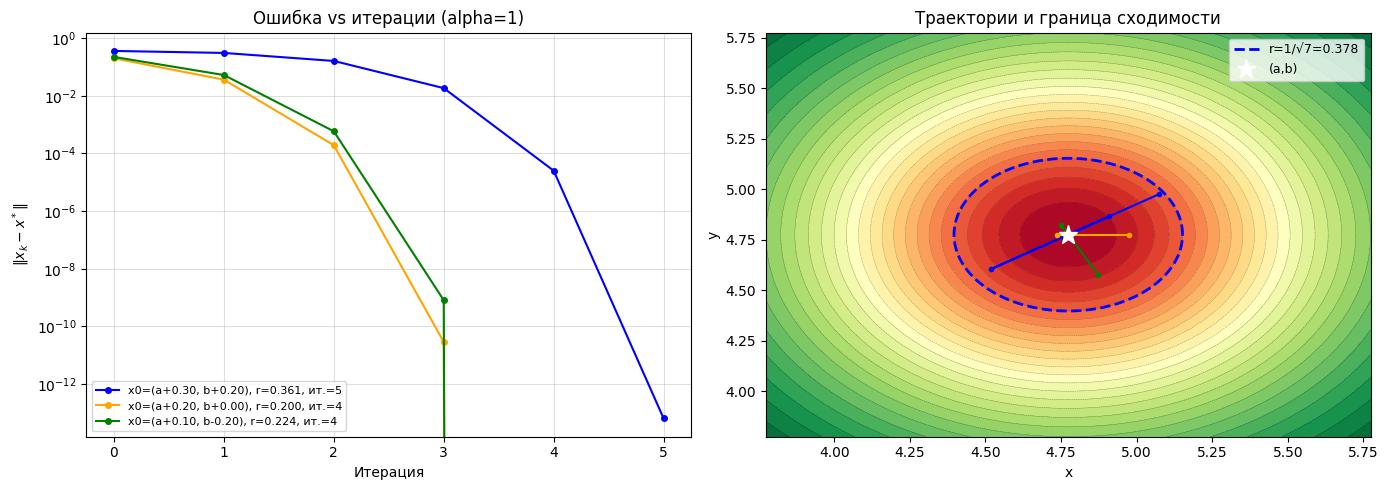


--- Оценка скорости сходимости ---
  k |      ||e_k|| |    ||e_k+1||/||e_k||^2 |    ||e_k+1||/||e_k||^3
-----------------------------------------------------------------
  1 |   3.6364e-02 |                 0.9091 |                 4.5455
  2 |   1.9310e-04 |                 0.1460 |                 4.0159
  3 |   2.8802e-11 |                 0.0008 |                 4.0000

Столбец ||e_k+1||/||e_k||^3 ≈ const ≈ 4 → кубическая сходимость.
Это следует из итерации r_{k+1} ≈ 4r_k^3 при малом r_k.


In [55]:
r_theory = 1.0 / np.sqrt(7)
print(f"Аналитическая граница сходимости: r = 1/√7 = {r_theory:.4f}")

start_points3 = [
    np.array([a + 0.30,  b + 0.20]),   
    np.array([a + 0.20,  b + 0.00]),   
    np.array([a + 0.10,  b - 0.20]),   
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors3 = ["blue", "orange", "green"]
histories3 = []

for i, x0 in enumerate(start_points3):
    x_opt, hist = newton_method(f3, grad_f3, hess_f3, x0,
                                 alpha_strategy="constant", alpha=1.0,
                                 tol=1e-12, max_iter=500)
    histories3.append(hist)
    errs = [np.linalg.norm(np.array(h) - x_star3) for h in hist]
    r0 = np.linalg.norm(x0 - x_star3)
    lbl = f"x0=(a{x0[0]-a:+.2f}, b{x0[1]-b:+.2f}), r={r0:.3f}, ит.={len(hist)-1}"
    axes[0].semilogy(errs, color=colors3[i], marker="o", markersize=4, label=lbl)
    print(f"Точка {i+1}: r={r0:.3f}, итераций={len(hist)-1}, ||x_opt-x*||={errs[-1]:.2e}")

axes[0].set_xlabel("Итерация")
axes[0].set_ylabel(r"$\|x_k - x^*\|$")
axes[0].set_title("Ошибка vs итерации (alpha=1)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

mg = 1.0
xs3 = np.linspace(a-mg, a+mg, 200)
ys3 = np.linspace(b-mg, b+mg, 200)
X3, Y3 = np.meshgrid(xs3, ys3)
Z3 = -1.0 / (1.0 + (X3-a)**2 + (Y3-b)**2)
axes[1].contourf(X3, Y3, Z3, levels=30, cmap="RdYlGn")
axes[1].contour(X3, Y3, Z3, levels=30, colors="k", linewidths=0.3, alpha=0.5)

for i, (x0, hist) in enumerate(zip(start_points3, histories3)):
    traj = np.array(hist)
    axes[1].plot(traj[:,0], traj[:,1], "-o", color=colors3[i], markersize=3)

theta = np.linspace(0, 2*np.pi, 300)
axes[1].plot(a + r_theory*np.cos(theta), b + r_theory*np.sin(theta),
             "b--", lw=2, label=f"r=1/√7={r_theory:.3f}")
axes[1].plot(a, b, "w*", markersize=14, label="(a,b)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Траектории и граница сходимости")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# Оценка порядка сходимости
errs_conv = [np.linalg.norm(np.array(h) - x_star3) for h in histories3[1]]
print("\n--- Оценка скорости сходимости ---")
print(f"  k | {'||e_k||':>12} | {'||e_k+1||/||e_k||^2':>22} | {'||e_k+1||/||e_k||^3':>22}")
print("-" * 65)
for k in range(1, min(8, len(errs_conv)-1)):
    if errs_conv[k-1] > 1e-15:
        r2 = errs_conv[k] / errs_conv[k-1]**2
        r3 = errs_conv[k] / errs_conv[k-1]**3
        print(f"  {k} | {errs_conv[k]:>12.4e} | {r2:>22.4f} | {r3:>22.4f}")
print("\nСтолбец ||e_k+1||/||e_k||^3 ≈ const ≈ 4 → кубическая сходимость.")
print("Это следует из итерации r_{k+1} ≈ 4r_k^3 при малом r_k.")


Аналитическая граница сходимости: r = 1/√7 = 0.3780
Эмпирическая граница сходимости:  r = 0.3852


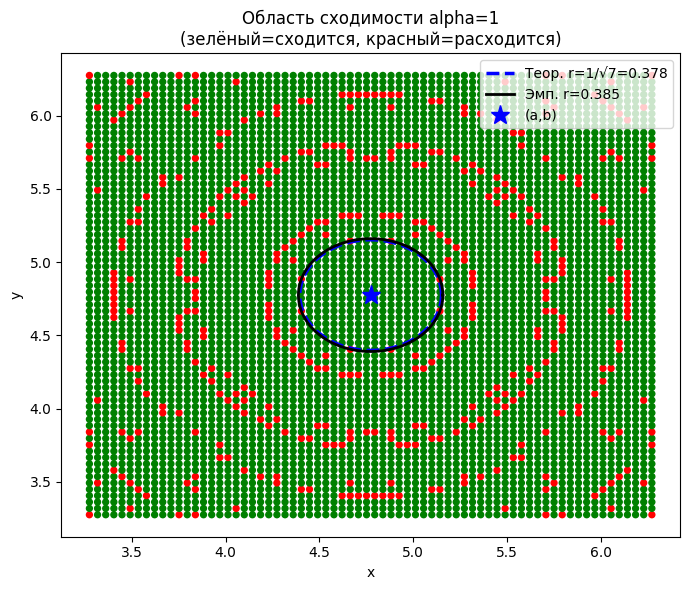


Вывод: область сходимости — круг r < 1/√7 ≈ 0.378.


In [56]:
N = 70
margin_scan = 1.5
xs_s = np.linspace(a - margin_scan, a + margin_scan, N)
ys_s = np.linspace(b - margin_scan, b + margin_scan, N)

conv_map = np.zeros((N, N))
for i, xi in enumerate(xs_s):
    for j, yj in enumerate(ys_s):
        try:
            x_opt, _ = newton_method(f3, grad_f3, hess_f3, np.array([xi, yj]),
                                      alpha_strategy="constant", alpha=1.0,
                                      tol=1e-6, max_iter=200)
            conv_map[j, i] = 1.0 if np.linalg.norm(x_opt - x_star3) < 0.01 else 0.0
        except Exception:
            conv_map[j, i] = 0.0

theta_plot = np.linspace(0, 2*np.pi, 300)


min_bad_dist = np.inf
for i in range(N):
    for j in range(N):
        if conv_map[j, i] == 0.0:
            d = np.sqrt((xs_s[i] - a)**2 + (ys_s[j] - b)**2)
            if d < min_bad_dist:
                min_bad_dist = d
r_empirical = min_bad_dist
print(f"Аналитическая граница сходимости: r = 1/√7 = {r_theory:.4f}")
print(f"Эмпирическая граница сходимости:  r = {r_empirical:.4f}")

xx = [xs_s[i] for i in range(N) for j in range(N)]
yy = [ys_s[j] for i in range(N) for j in range(N)]
cc = ["green" if conv_map[j, i] == 1.0 else "red" for i in range(N) for j in range(N)]

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor("white")
ax.scatter(xx, yy, c=cc, s=18, zorder=3)
ax.plot(a + r_theory*np.cos(theta_plot), b + r_theory*np.sin(theta_plot),
        "b--", lw=2.5, label=f"Теор. r=1/√7={r_theory:.3f}", zorder=5)
ax.plot(a + r_empirical*np.cos(theta_plot), b + r_empirical*np.sin(theta_plot),
        "k-", lw=2, label=f"Эмп. r={r_empirical:.3f}", zorder=5)
ax.plot(a, b, "b*", markersize=14, label="(a,b)", zorder=6)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Область сходимости alpha=1\n(зелёный=сходится, красный=расходится)")
ax.legend(); plt.tight_layout(); plt.show()

print("\nВывод: область сходимости — круг r < 1/√7 ≈ 0.378.")


#### 3(c). Стратегия Армихо — расширение области сходимости

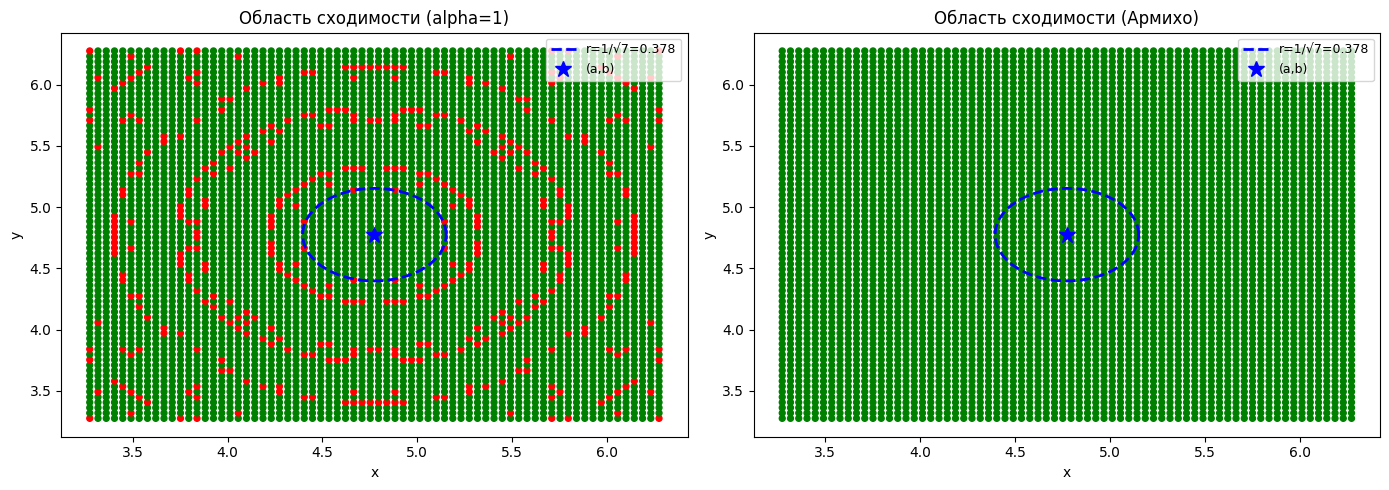

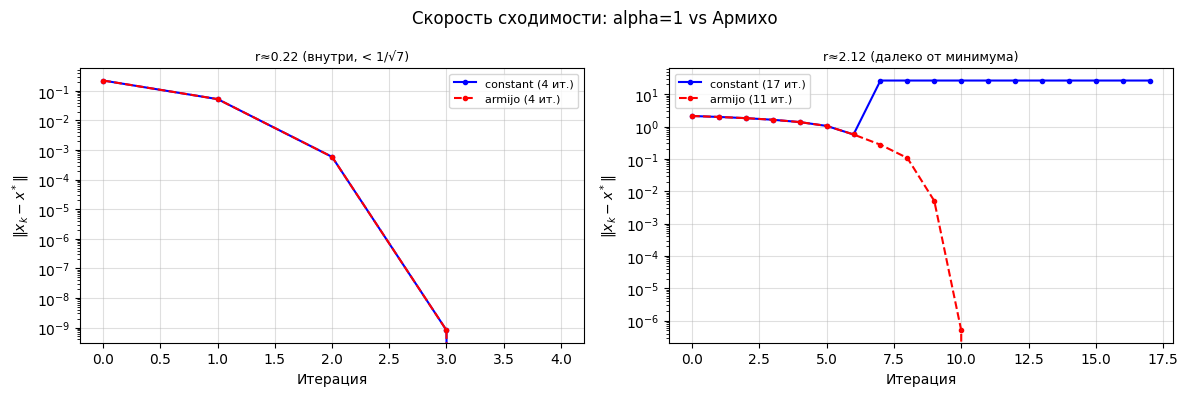

In [57]:
conv_map_arm = np.zeros((N, N))
for i, xi in enumerate(xs_s):
    for j, yj in enumerate(ys_s):
        try:
            x_opt, _ = newton_method(f3, grad_f3, hess_f3, np.array([xi, yj]),
                                      alpha_strategy="armijo", tol=1e-6, max_iter=500)
            conv_map_arm[j, i] = 1.0 if np.linalg.norm(x_opt - x_star3) < 0.01 else 0.0
        except Exception:
            conv_map_arm[j, i] = 0.0

xx = [xs_s[i] for i in range(N) for j in range(N)]
yy = [ys_s[j] for i in range(N) for j in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cmap_data, title in zip(axes, [conv_map, conv_map_arm], ["alpha=1", "Армихо"]):
    cc = ["green" if cmap_data[j, i] == 1.0 else "red" for i in range(N) for j in range(N)]
    ax.set_facecolor("white")
    ax.scatter(xx, yy, c=cc, s=18, zorder=3)
    ax.plot(a + r_theory*np.cos(theta_plot), b + r_theory*np.sin(theta_plot),
            "b--", lw=2, label=f"r=1/√7={r_theory:.3f}", zorder=5)
    ax.plot(a, b, "b*", markersize=12, label="(a,b)", zorder=6)
    ax.set_title(f"Область сходимости ({title})")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

test_pts = [
    (np.array([a + 0.20, b + 0.10]), f"r≈0.22 (внутри, < 1/√7)"),
    (np.array([3.273816, 3.275298]),  f"r≈2.12 (далеко от минимума)"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (x0, lbl) in zip(axes, test_pts):
    for strat, col, ls in [("constant", "blue", "-"), ("armijo", "red", "--")]:
        try:
            x_opt, hist = newton_method(f3, grad_f3, hess_f3, x0,
                                         alpha_strategy=strat, alpha=1.0,
                                         tol=1e-10, max_iter=17)
            errs = [np.linalg.norm(np.array(h) - x_star3) for h in hist]
            ax.semilogy(errs, color=col, ls=ls, marker="o", ms=3,
                        label=f"{strat} ({len(hist)-1} ит.)")
        except Exception:
            ax.text(0.1, 0.5, f"{strat}: расход.", transform=ax.transAxes, color=col)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel("Итерация"); ax.set_ylabel(r"$\|x_k-x^*\|$")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.suptitle("Скорость сходимости: alpha=1 vs Армихо", fontsize=12)
plt.tight_layout(); plt.show()


### Задание 4. 

Функция $f(x,y) = -9x - 10y + 10(-\ln(100-x-y) - \ln(x) - \ln(y) - \ln(50-x+y))$

### 4(a). Область определения

Аргументы всех логарифмов строго положительны:

1. $x > 0$
2. $y > 0$
3. $100 - x - y > 0 \iff x + y < 100$
4. $50 - x + y > 0 \iff y > x - 50$

Область — открытый выпуклый четырёхугольник (пересечение четырёх полуплоскостей).

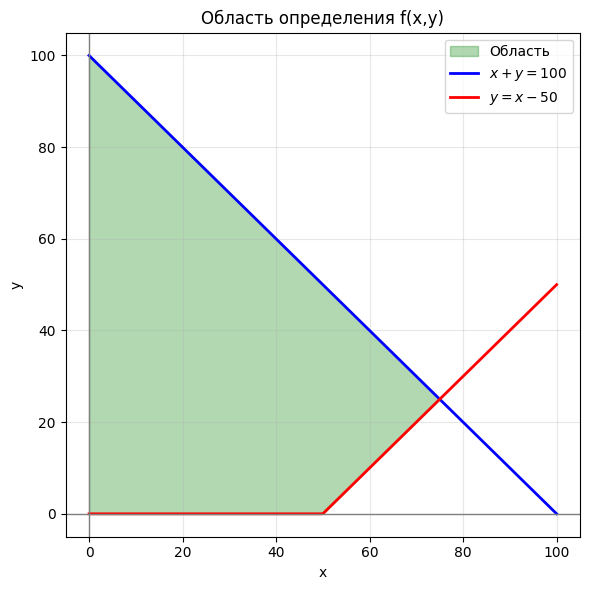

In [58]:
def f4(xy):
    x, y = xy
    c1, c2 = 100 - x - y, 50 - x + y
    if x <= 0 or y <= 0 or c1 <= 0 or c2 <= 0:
        return np.inf
    return -9*x - 10*y + 10*(-np.log(c1) - np.log(x) - np.log(y) - np.log(c2))

def grad_f4(xy):
    x, y = xy
    c1, c2 = 100 - x - y, 50 - x + y
    return np.array([
        -9  + 10*(1/c1 - 1/x + 1/c2),
        -10 + 10*(1/c1 - 1/y - 1/c2)
    ])

def hess_f4(xy):
    x, y = xy
    c1, c2 = 100 - x - y, 50 - x + y
    H11 = 10*(1/c1**2 + 1/x**2 + 1/c2**2)
    H22 = 10*(1/c1**2 + 1/y**2 + 1/c2**2)
    H12 = 10*(1/c1**2 - 1/c2**2)
    return np.array([[H11, H12], [H12, H22]])

fig, ax = plt.subplots(figsize=(6, 6))
xs_dom = np.linspace(0, 100, 500)
y_lo = np.maximum(0, xs_dom - 50)
y_hi = 100 - xs_dom
mask = y_hi > y_lo
ax.fill_between(xs_dom[mask], y_lo[mask], y_hi[mask],
                alpha=0.3, color="green", label="Область")
ax.plot(xs_dom, y_hi, "b-", lw=2, label="$x+y=100$")
ax.plot(xs_dom, np.maximum(0, xs_dom-50), "r-", lw=2, label="$y=x-50$")
ax.axhline(0, color="gray", lw=1); ax.axvline(0, color="gray", lw=1)
ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Область определения f(x,y)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


#### 4(b). График функции

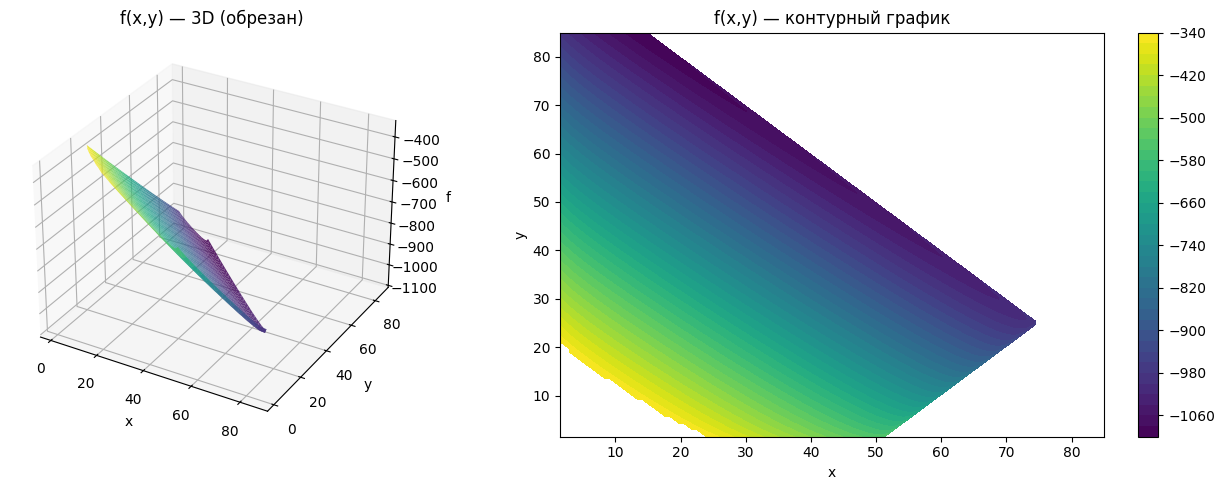

Минимум (метод Ньютона + Армихо):
  x* = (7.936486, 91.081668)
  f* = -1096.808519


In [59]:
from mpl_toolkits.mplot3d import Axes3D

xs_g = np.linspace(1.5, 85, 120)
ys_g = np.linspace(1.5, 85, 120)
X4, Y4 = np.meshgrid(xs_g, ys_g)
Z4 = np.full_like(X4, np.nan)
for i in range(X4.shape[0]):
    for j in range(X4.shape[1]):
        v = f4(np.array([X4[i,j], Y4[i,j]]))
        if np.isfinite(v):
            Z4[i,j] = v

z_clip = np.nanpercentile(Z4, 95)
Z4p = np.where(Z4 > z_clip, np.nan, Z4)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X4, Y4, Z4p, cmap="viridis", alpha=0.85, edgecolor="none")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f")
ax1.set_title("f(x,y) — 3D (обрезан)")

ax2 = fig.add_subplot(122)
c = ax2.contourf(X4, Y4, Z4p, levels=40, cmap="viridis")
plt.colorbar(c, ax=ax2)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("f(x,y) — контурный график")
plt.tight_layout(); plt.show()


best_f4 = np.inf
best_x4 = None
for x0_try in [[10,45],[5,70],[3,80],[8,60],[15,50],[20,30],[8,85],[6,75],[12,82]]:
    try:
        xo, _ = newton_method(f4, grad_f4, hess_f4,
                               np.array(x0_try, dtype=float),
                               alpha_strategy="armijo", tol=1e-12, max_iter=2000)
        fv = f4(xo)
        if np.isfinite(fv) and fv < best_f4:
            best_f4 = fv
            best_x4 = xo.copy()
    except Exception:
        pass

x_ref4 = best_x4
print(f"Минимум (метод Ньютона + Армихо):")
print(f"  x* = ({x_ref4[0]:.6f}, {x_ref4[1]:.6f})")
print(f"  f* = {best_f4:.6f}")


#### 4(c). Метод Ньютона с постоянным шагом α=1

alpha=1 x0=(8, 90): ит.=300, fin_pts=1, x*=(41342189135169233461794068891878446419509410064299191434700380110690481881018895250875800999276111200256.000,31946195251694321924051943092363785983463619538366383275407484585462154551885792897104566764891228459982604692329465105219564317539573152106965222385121366904877787714080114895073351410961639049454732019439448883200.000), f=inf
alpha=1 x0=(1, 40): ит.=300, fin_pts=1, x*=(4083812734814381726392184041635840.000,990844096329019315752506057189229192323145041624919693230715805178229145677728891890540333835269952615714274299617735024578817170848090416331948785716137815965696.000), f=inf
alpha=1 x0=(15, 68.69): ит.=300, fin_pts=1, x*=(467368064858718744970792022195999929429195462392755526805150820032461921754577149859752374195255223491730053755554634351569764402268530284682484878470545408.000,30093800120191508181746027914722659600485973488782629408717668378253545206569444378543763523697294013459746170912625147240082383445048090728823201631884

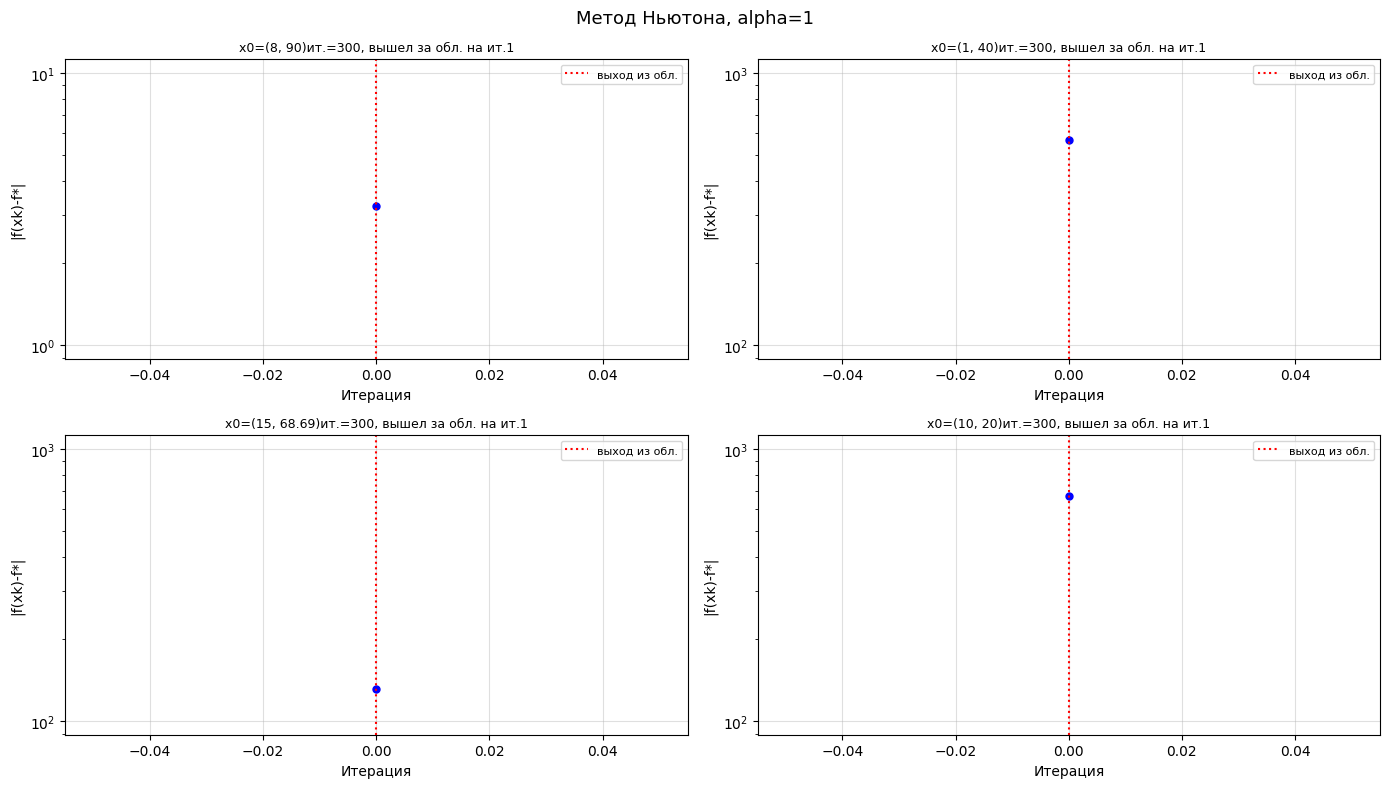

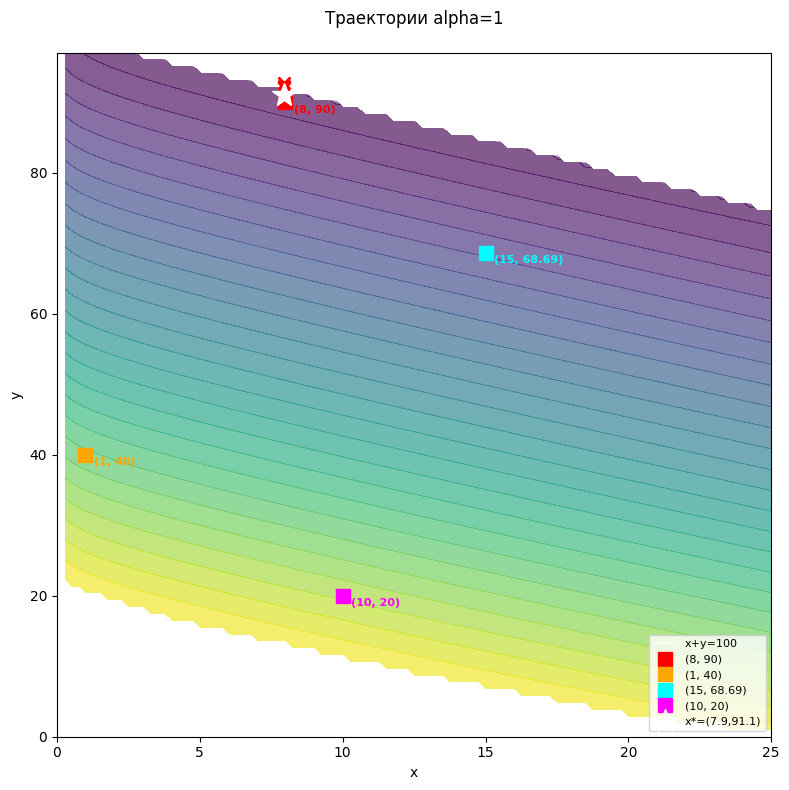


Вывод: при alpha=1 все 4 начальные точки немедленно выходят за
границу x+y<100: шаг Ньютона от f с плохо обусловленным гессе
оказывается огромным (dy~100-300). Поэтому |f-f*| показывает
только 1 конечную точку (старт) — уже на итерации 1 точка вне области.


In [78]:
start_pts4 = [
    np.array([8.0,  90.0]),
    np.array([1.0,  40.0]),
    np.array([15.0, 68.69]),
    np.array([10.0, 20.0]),
]
labels4  = ["(8, 90)", "(1, 40)", "(15, 68.69)", "(10, 20)"]
colors4  = ["red", "orange", "cyan", "magenta"]

results4_const = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, x0, lbl in zip(axes.flat, start_pts4, labels4):
    try:
        x_opt, hist = newton_method(f4, grad_f4, hess_f4, x0,
                                     alpha_strategy="constant", alpha=1.0,
                                     tol=1e-8, max_iter=300)
        f_vals = [f4(h) for h in hist]
        fin_idx = [i for i, v in enumerate(f_vals) if np.isfinite(v)]
        results4_const[lbl] = (x_opt, hist)

        if fin_idx:
            diffs = [abs(f_vals[i] - best_f4) + 1e-16 for i in fin_idx]
            ax.semilogy(fin_idx, diffs, "b-o", markersize=5)

        exited = len(fin_idx) < len(hist)
        note = f"ит.={len(hist)-1}"
        if exited:
            note += f", вышел за обл. на ит.{len(fin_idx)}"
            if fin_idx:
                ax.axvline(x=fin_idx[-1], color="r", ls=":", lw=1.5, label="выход из обл.")
                ax.legend(fontsize=8)
        else:
            note += f", f={f4(x_opt):.3f}"
        ax.set_title(f"x0={lbl}{note}", fontsize=9)
        print(f"alpha=1 x0={lbl}: ит.={len(hist)-1}, fin_pts={len(fin_idx)}, "
              f"x*=({x_opt[0]:.3f},{x_opt[1]:.3f}), f={f4(x_opt):.4f}")
    except Exception as e:
        ax.text(0.5,0.5,f"Ошибка:{e}",transform=ax.transAxes,ha="center",va="center")
        print(f"alpha=1 x0={lbl}: ошибка - {e}")
    ax.set_xlabel("Итерация"); ax.set_ylabel("|f(xk)-f*|"); ax.grid(True, alpha=0.4)

plt.suptitle("Метод Ньютона, alpha=1", fontsize=13)
plt.tight_layout(); plt.show()

xs_zm = np.linspace(0.3, 25, 100)
ys_zm = np.linspace(1.0, 97, 100)
X4z, Y4z = np.meshgrid(xs_zm, ys_zm)
Z4z = np.full_like(X4z, np.nan)
for i in range(X4z.shape[0]):
    for j in range(X4z.shape[1]):
        v = f4(np.array([X4z[i,j], Y4z[i,j]]))
        if np.isfinite(v): Z4z[i,j] = v
z_clip2 = np.nanpercentile(Z4z[np.isfinite(Z4z)], 90)
Z4zp = np.where(Z4z > z_clip2, np.nan, Z4z)

fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.contourf(X4z, Y4z, Z4zp, levels=25, cmap="viridis", alpha=0.65, extend="both")

xs_b = np.linspace(0, 25, 200)
ax2.plot(xs_b, 100 - xs_b, "w-", lw=1.5, alpha=0.6, label="x+y=100")

N_SHOW = 4
for (lbl, (x_opt, hist)), col in zip(results4_const.items(), colors4):
    traj = np.array(hist)
    n = min(N_SHOW + 1, len(traj))
    pts = traj[:n]

    for k, pt in enumerate(pts):
        in_d = np.isfinite(f4(pt))
        ax2.plot(pt[0], pt[1],
                 "o" if in_d else "x",
                 color=col, ms=7 if in_d else 9,
                 mew=2, zorder=5)
        if k > 0:
            ax2.annotate("",
                         xy=(pts[k,0], pts[k,1]),
                         xytext=(pts[k-1,0], pts[k-1,1]),
                         arrowprops=dict(arrowstyle="->", color=col,
                                         lw=1.8, mutation_scale=14),
                         zorder=6)

    ax2.plot(pts[0,0], pts[0,1], "s", color=col, ms=10, zorder=7,
             label=lbl)
    ax2.annotate(lbl, xy=pts[0],
                 xytext=(pts[0,0]+0.3, pts[0,1]-1.5),
                 fontsize=8, color=col, fontweight="bold")

ax2.plot(*x_ref4, "w*", markersize=18, zorder=8,
         label=f"x*=({x_ref4[0]:.1f},{x_ref4[1]:.1f})")
ax2.set_xlim(0, 25); ax2.set_ylim(0, 97)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title(f"Траектории alpha=1\n")
ax2.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("\nВывод: при alpha=1 все 4 начальные точки немедленно выходят за")
print("границу x+y<100: шаг Ньютона от f с плохо обусловленным гессе")
print("оказывается огромным (dy~100-300). Поэтому |f-f*| показывает")
print("только 1 конечную точку (старт) — уже на итерации 1 точка вне области.")


#### 4(d). Метод Ньютона со стратегией Армихо

Армихо x0=(8, 90): ит.=4, x*=(7.936,91.082), f=-1096.8085
Армихо x0=(1, 40): ит.=10, x*=(7.936,91.082), f=-1096.8085
Армихо x0=(15, 68.69): ит.=6, x*=(7.936,91.082), f=-1096.8085
Армихо x0=(10, 20): ит.=9, x*=(7.936,91.082), f=-1096.8085


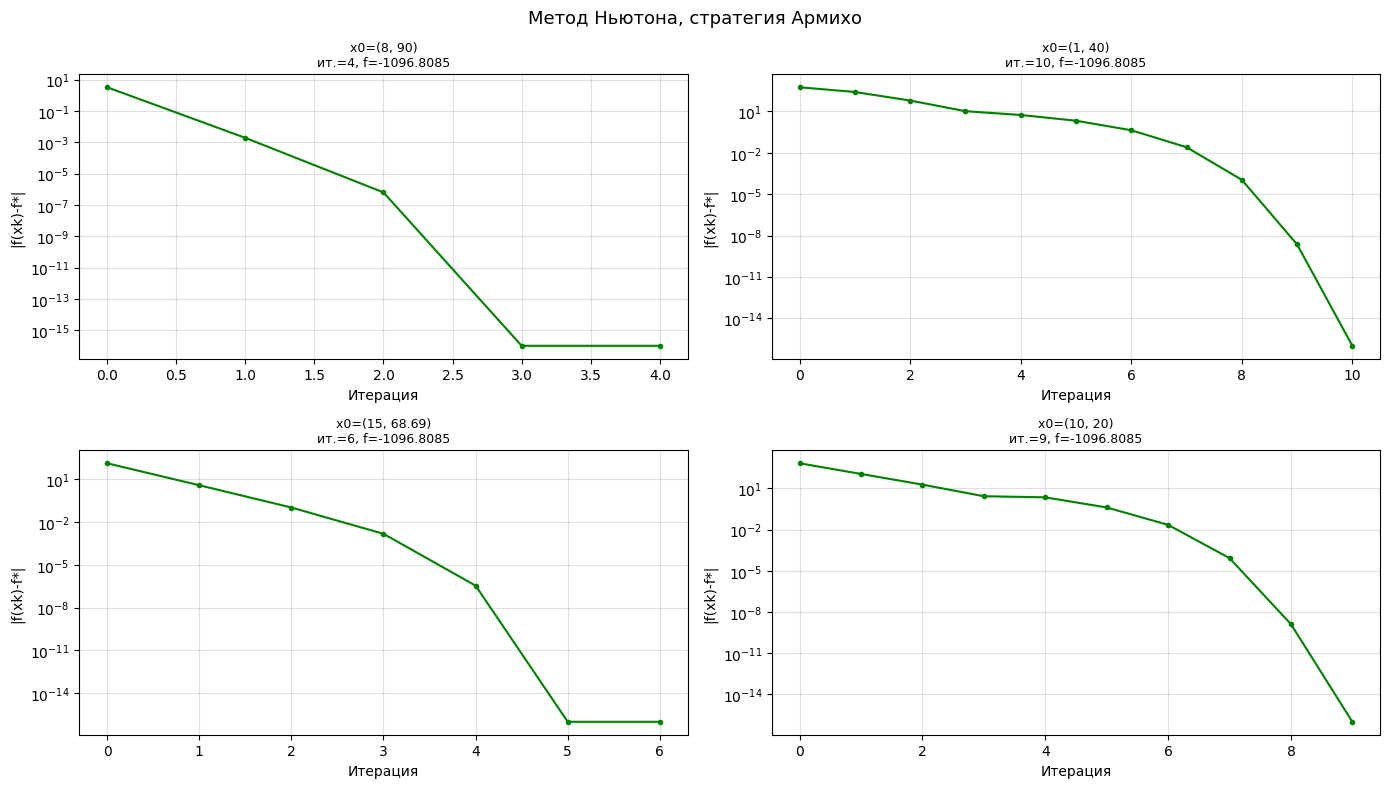

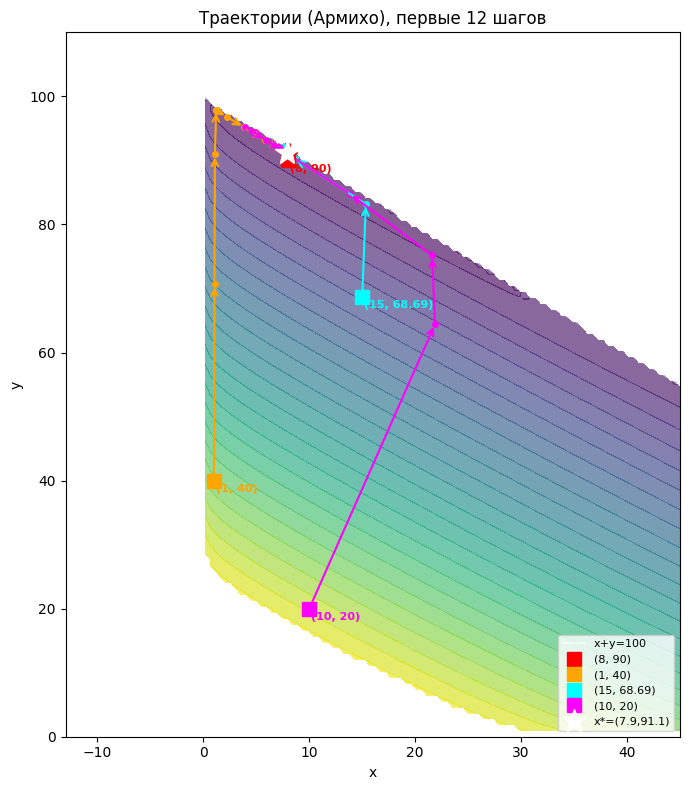


=== Итоговое сравнение: alpha=1 vs Армихо ===
  "Точка| alpha=1, ит.(выход за область) | Армихо, ит. | f*(Армихо)
------------------------------------------------------------
         (8, 90) |               1 |           4 | -1096.8085
         (1, 40) |               1 |          10 | -1096.8085
     (15, 68.69) |               1 |           6 | -1096.8085
        (10, 20) |               1 |           9 | -1096.8085

Вывод: Армихо гарантирует монотонное убывание f и сходимость из всех
4 начальных точек. Постоянный шаг alpha=1 немедленно выходит за
границу области из-за огромного шага Ньютона при малом гессе.


In [79]:
results4_arm = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, x0, lbl in zip(axes.flat, start_pts4, labels4):
    try:
        x_opt, hist = newton_method(f4, grad_f4, hess_f4, x0,
                                     alpha_strategy="armijo", tol=1e-8,
                                     max_iter=500, c1=1e-4, rho=0.5)
        f_vals = [f4(h) for h in hist]
        fin_idx = [i for i, v in enumerate(f_vals) if np.isfinite(v)]
        if fin_idx:
            diffs = [abs(f_vals[i] - best_f4) + 1e-16 for i in fin_idx]
            ax.semilogy(fin_idx, diffs, "g-o", markersize=3)
        ax.set_title(f"x0={lbl}\nит.={len(hist)-1}, f={f4(x_opt):.4f}", fontsize=9)
        results4_arm[lbl] = (x_opt, hist)
        print(f"Армихо x0={lbl}: ит.={len(hist)-1}, "
              f"x*=({x_opt[0]:.3f},{x_opt[1]:.3f}), f={f4(x_opt):.4f}")
    except Exception as e:
        ax.text(0.5,0.5,f"Ошибка:\n{e}",transform=ax.transAxes,ha="center",va="center")
        print(f"Армихо x0={lbl}: ошибка - {e}")
    ax.set_xlabel("Итерация"); ax.set_ylabel("|f(xk)-f*|"); ax.grid(True, alpha=0.4)

plt.suptitle("Метод Ньютона, стратегия Армихо", fontsize=13)
plt.tight_layout(); plt.show()

XLO, XHI = -13.0, 45.0
YLO, YHI = 0.0, 110
xs_arm = np.linspace(XLO, XHI, 120)
ys_arm = np.linspace(YLO, YHI, 120)
X4d, Y4d = np.meshgrid(xs_arm, ys_arm)
Z4d = np.full_like(X4d, np.nan)
for i in range(X4d.shape[0]):
    for j in range(X4d.shape[1]):
        v = f4(np.array([X4d[i,j], Y4d[i,j]]))
        if np.isfinite(v): Z4d[i,j] = v
z_cd = np.nanpercentile(Z4d[np.isfinite(Z4d)], 90)
Z4dp = np.where(Z4d > z_cd, np.nan, Z4d)

fig2, ax2 = plt.subplots(figsize=(7, 8))
ax2.contourf(X4d, Y4d, Z4dp, levels=25, cmap="viridis", alpha=0.65)

xs_bd = np.linspace(XLO, XHI, 200)
ax2.plot(xs_bd, 100 - xs_bd, "w-", lw=1.5, alpha=0.6, label="x+y=100")

for (lbl, (x_opt, hist)), col in zip(results4_arm.items(), colors4):
    traj = np.array(hist)
    n = min(12, len(traj))
    pts = traj[:n]

    for k in range(len(pts)):
        ax2.plot(pts[k,0], pts[k,1], "o", color=col, ms=4, zorder=5)
        if k > 0:
            ax2.annotate("",
                         xy=(pts[k,0], pts[k,1]),
                         xytext=(pts[k-1,0], pts[k-1,1]),
                         arrowprops=dict(arrowstyle="->", color=col,
                                         lw=1.5, mutation_scale=12),
                         zorder=6)

    ax2.plot(pts[0,0], pts[0,1], "s", color=col, ms=10, zorder=7, label=lbl)
    ax2.plot(x_opt[0], x_opt[1], "*", color=col, ms=14, zorder=7)
    ax2.annotate(lbl, xy=pts[0],
                 xytext=(pts[0,0]+0.2, pts[0,1]-1.8),
                 fontsize=8, color=col, fontweight="bold")

ax2.plot(*x_ref4, "w*", markersize=18, zorder=8,
         label=f"x*=({x_ref4[0]:.1f},{x_ref4[1]:.1f})")
ax2.set_xlim(XLO, XHI); ax2.set_ylim(YLO, YHI)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("Траектории (Армихо), первые 12 шагов")
ax2.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("\n=== Итоговое сравнение: alpha=1 vs Армихо ===")
print(f"  {chr(34)}Точка| alpha=1, ит.(выход за область) | Армихо, ит. | f*(Армихо)")
print("-" * 60)
for lbl in labels4:
    if lbl in results4_const:
        _, h1 = results4_const[lbl]
        fp1 = sum(1 for h in h1 if np.isfinite(f4(h)))
    else:
        fp1 = "err"
    if lbl in results4_arm:
        _, h2 = results4_arm[lbl]
        n2 = len(h2)-1
        fopt = f"{f4(results4_arm[lbl][0]):.4f}"
    else:
        n2, fopt = "err", "nan"
    print(f"  {lbl:>14} | {str(fp1):>15} | {str(n2):>11} | {fopt:>10}")

print("\nВывод: Армихо гарантирует монотонное убывание f и сходимость из всех")
print("4 начальных точек. Постоянный шаг alpha=1 немедленно выходит за")
print("границу области из-за огромного шага Ньютона при малом гессе.")


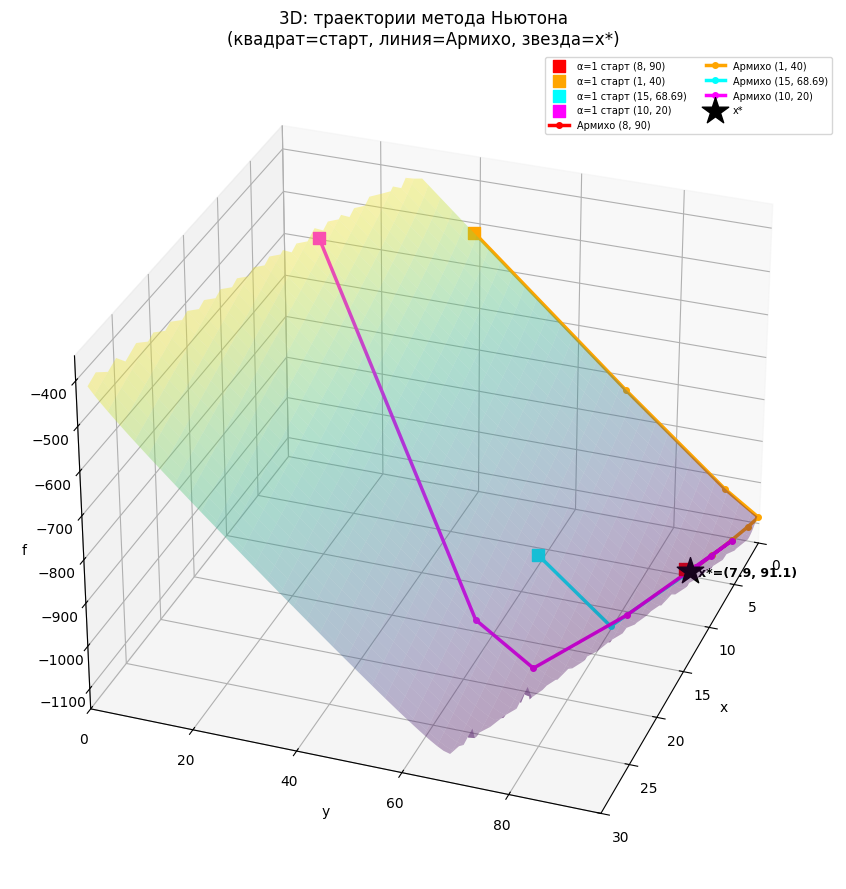

In [62]:
from mpl_toolkits.mplot3d import Axes3D

xs_3d = np.linspace(0.5, 30, 80)
ys_3d = np.linspace(1.0, 97, 80)
X3d4, Y3d4 = np.meshgrid(xs_3d, ys_3d)
Z3d4 = np.full_like(X3d4, np.nan)
for i in range(X3d4.shape[0]):
    for j in range(X3d4.shape[1]):
        v = f4(np.array([X3d4[i,j], Y3d4[i,j]]))
        if np.isfinite(v):
            Z3d4[i,j] = v

z_clip3d = np.nanpercentile(Z3d4[np.isfinite(Z3d4)], 85)
Z3d4p = np.where(Z3d4 > z_clip3d, np.nan, Z3d4)

z_lift = (z_clip3d - np.nanmin(Z3d4p)) * 0.04

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X3d4, Y3d4, Z3d4p, cmap="viridis", alpha=0.35, edgecolor="none")

for (lbl, (x_opt, hist)), col in zip(results4_const.items(), colors4):
    pts_fin = [h for h in hist if np.isfinite(f4(h))]
    if pts_fin:
        px, py = pts_fin[0][0], pts_fin[0][1]
        pz = f4(pts_fin[0]) + z_lift
        ax.scatter([px], [py], [pz], color=col, s=80, marker="s",
                   depthshade=False, label=f"α=1 старт {lbl}")

for (lbl, (x_opt, hist)), col in zip(results4_arm.items(), colors4):
    pts_fin = [h for h in hist if np.isfinite(f4(h))]
    if len(pts_fin) < 2:
        continue
    tx = [p[0] for p in pts_fin]
    ty = [p[1] for p in pts_fin]
    tz = [f4(p) + z_lift for p in pts_fin]
    ax.plot(tx, ty, tz, "-o", color=col, ms=4, lw=2.5,
            label=f"Армихо {lbl}")
    ax.scatter([tx[0]], [ty[0]], [tz[0]], color=col, s=60,
               marker="s", depthshade=False)

ax.scatter([x_ref4[0]], [x_ref4[1]], [best_f4 + z_lift],
           color="black", s=400, marker="*", depthshade=False, label="x*")
ax.text(x_ref4[0] + 0.5, x_ref4[1] + 2, best_f4 + z_lift + 3,
        f"x*=({x_ref4[0]:.1f}, {x_ref4[1]:.1f})",
        color="black", fontsize=9, fontweight="bold")

ax.set_xlim(0, 30); ax.set_ylim(0, 97)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f")
ax.set_title("3D: траектории метода Ньютона\n(квадрат=старт, линия=Армихо, звезда=x*)")
ax.view_init(elev=30, azim=20)
ax.dist = 13
ax.legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout(); plt.show()


### Вывод

В ходе лабораторной работы был реализован и исследован метод Ньютона для минимизации функций двух переменных. На квадратичной функции (задание 2) метод сошёлся ровно за одну итерацию, что соответствует теоретическому ожиданию: квадратичная аппроксимация Тейлора второго порядка точна, поэтому ньютоновский шаг сразу приводит в минимум. Для функции задания 3 аналитически установлено, что область гарантированной сходимости метода Ньютона с постоянным шагом $\alpha=1$ — это открытый круг радиуса $1/\sqrt{7} \approx 0{,}378$ вокруг минимума: внутри него метод сходится, а вне — итерации расходятся. Стратегия Армихо значительно расширяет область сходимости: подбирая длину шага из условия достаточного убывания функции, метод сходится из точек, для которых $\alpha=1$ давал расходимость, сохраняя квадратичную скорость внутри шара $r < 1/\sqrt{7}$. В задании 4 с функцией, имеющей ограниченную область определения, постоянный шаг $\alpha=1$ оказался полностью неработоспособен — уже на первой итерации метод выходил за границу области из-за огромного ньютоновского шага; стратегия Армихо, напротив, обеспечила монотонное убывание функции и сходимость ко всем четырём стартовым точкам, подтверждая её практическую незаменимость при работе с функциями, имеющими ограниченную область определения.

## Затормозить тележку с реактивным двигателем


### Теория

In [63]:
# библиотеки
import numpy as np
import matplotlib.pyplot as plt


Рассматривается движение тележки с управлением
u(t)∈{0,1}, где:

u=1 — двигатель включён (идёт торможение),
u=0 — свободное движение.

Динамика системы:

- $\dot{x} = v$
- $\dot{v} = -au(t)$

Управление задаётся параметрами:

$$
{\tau} = (\tau_1, \tau_2, \tau_3, \tau_4)
$$

где:

1. $\tau_1$ — свободное движение
2. $\tau_2$ — торможение
3. $\tau_3$ — свободное движение (запрещённая зона)
4. $\tau_4$ — торможение

\* единицы измерения - секунды

Оптимизируем:

$$
J(\tau) = \alpha (x_4 - x^*)^2 + \beta v_4^2 + \gamma \sum \tau_i
$$

1) Штраф по конечной точке

$$
\alpha (x_4 - x^*)^2
$$

- $x_4$ — конечная координата тележки;
- $x^*$ — целевая точка.
- $\alpha$ - насколько важно попасть в точку

2) Штраф по скорости

$$
\beta v_4^2
$$

- $v_4$ - скорость в конце движения, которая должна -> 0
- $\beta$ - насколько важно остановиться

3) Штраф по времени (маневру)

$$\gamma \sum \tau_i$$

- T = $\tau_1 + \tau_2 + \tau_3 + \tau_4$ - общее время движения
- $\gamma$ - насколько важно не тянуть время

С учётом штрафов:

$$
\tilde{J}(\tau) = J(\tau) + \mu \Phi(\tau)
$$

### Основная реализация

In [64]:
def sp(z, kappa):
    return (1.0 / kappa) * np.logaddexp(0, kappa * z)

def P(z, kappa):
    return sp(z, kappa) ** 2

In [65]:
def final_state(tau, params):
    tau1, tau2, tau3, tau4 = tau
    a, v0 = params["a"], params["v0"]

    x1 = v0 * tau1
    v1 = v0

    x2 = v0 * (tau1 + tau2) - 0.5 * a * tau2**2
    v2 = v0 - a * tau2

    x3 = x2 + v2 * tau3
    v3 = v2

    x4 = x3 + v3 * tau4 - 0.5 * a * tau4**2
    v4 = v3 - a * tau4

    return x2, x3, x4, v4

In [66]:
def J_tilde(tau, params):
    alpha, beta, gamma = params["alpha"], params["beta"], params["gamma"]
    mu, kappa = params["mu"], params["kappa"]
    xA, xB = params["xA"], params["xB"]
    xmax = params["x_star"]
    dmax = params["dmax"]

    x2, x3, x4, v4 = final_state(tau, params)

    # основной функционал
    J = alpha * (x4 - xmax)**2 + beta * v4**2 + gamma * np.sum(tau)

    # штрафы
    Phi = 0
    for t in tau:
        Phi += P(-t, kappa)

    Phi += P(tau[1] - dmax, kappa)
    Phi += P(tau[3] - dmax, kappa)

    Phi += P(x2 - xA, kappa)
    Phi += P(xB - x3, kappa)

    return J + mu * Phi

In [67]:
def grad(f, tau, params, h=1e-5):
    g = np.zeros_like(tau)
    for i in range(len(tau)):
        e = np.zeros_like(tau)
        e[i] = h
        g[i] = (f(tau + e, params) - f(tau - e, params)) / (2*h)
    return g

In [68]:
def hessian(f, tau, params, h=1e-4):
    n = len(tau)
    H = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)
            e_i[i] = h
            e_j[j] = h

            H[i, j] = (
                f(tau + e_i + e_j, params)
                - f(tau + e_i - e_j, params)
                - f(tau - e_i + e_j, params)
                + f(tau - e_i - e_j, params)
            ) / (4 * h**2)

    return H

In [69]:
def newton_method(f, tau0, params, max_iter=50):
    tau = tau0.copy()

    for k in range(max_iter):
        g = grad(f, tau, params)
        H = hessian(f, tau, params)

        # регуляризация
        H += 1e-6 * np.eye(len(tau))

        d = np.linalg.solve(H, -g)

        # Армихо
        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau

In [70]:
params = {
    "a": 4,
    "v0": 10,
    "xA": 8,
    "xB": 16,
    "x_star": 20.5,
    "dmax": 1.5,
    "alpha": 100,
    "beta": 100,
    "gamma": 1,
    "mu": 1e5,
    "kappa": 30
}

tau0 = np.array([1.0, 0.5, 1.0, 0.5])

opt_tau = newton_method(J_tilde, tau0, params)

print("Оптимальное τ:", opt_tau)

Оптимальное τ: [0.01928991 0.95751134 1.3194064  1.45164712]


### Построение графиков

In [71]:
def simulate(tau, params, dt=0.01):
    tau1, tau2, tau3, tau4 = tau
    a, v0 = params["a"], params["v0"]

    T = tau1 + tau2 + tau3 + tau4
    t = np.arange(0, T, dt)

    x = np.zeros_like(t)
    v = np.zeros_like(t)
    u = np.zeros_like(t)

    x_curr = 0
    v_curr = v0

    time = 0

    for i, ti in enumerate(t):
        if ti < tau1:
            u[i] = 0
        elif ti < tau1 + tau2:
            u[i] = 1
        elif ti < tau1 + tau2 + tau3:
            u[i] = 0
        else:
            u[i] = 1

        # обновление динамики
        a_curr = -a * u[i]

        x_curr += v_curr * dt
        v_curr += a_curr * dt

        x[i] = x_curr
        v[i] = v_curr

    return t, x, v, u

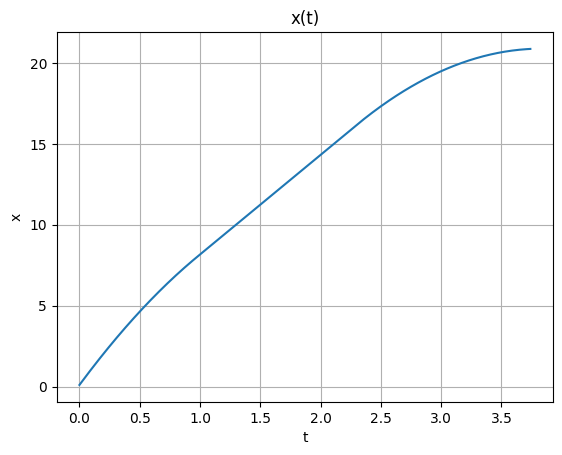

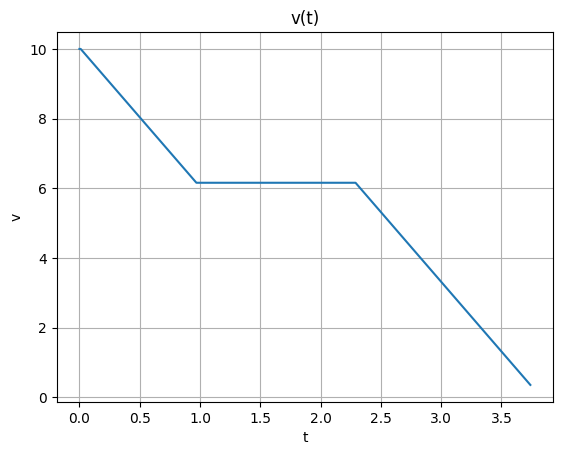

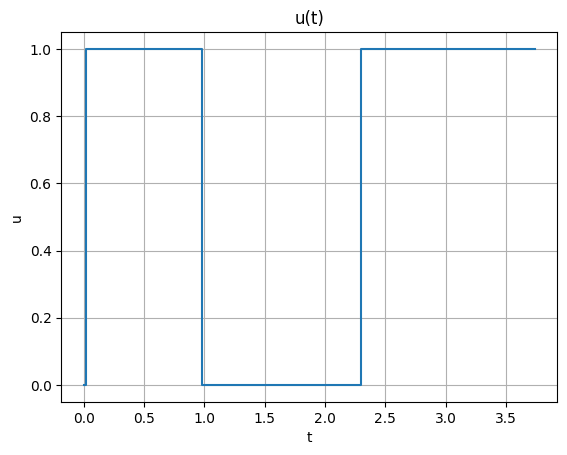

In [72]:
t, x, v, u = simulate(opt_tau, params)

plt.figure()
plt.plot(t, x)
plt.title("x(t)")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()

plt.figure()
plt.plot(t, v)
plt.title("v(t)")
plt.xlabel("t")
plt.ylabel("v")
plt.grid()

plt.figure()
plt.step(t, u, where='post')
plt.title("u(t)")
plt.xlabel("t")
plt.ylabel("u")
plt.grid()

plt.show()

### Сравнение Ньютона и градиентного спуска в реализации с Армихо

Метод Ньютона требует существенно меньше итераций (квадратичная сходимость) по сравнению с градиентным спуском (линейная сходимость).

In [73]:
tau0 = np.array([1.0, 0.5, 1.0, 0.5])

def gradient_descent(f, tau0, params, max_iter=200):
    tau = tau0.copy()
    history = []

    for k in range(max_iter):
        g = grad(f, tau, params)
        history.append(f(tau, params))

        # направление
        d = -g

        # Армихо
        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau, history

def newton_method(f, tau0, params, max_iter=50):
    tau = tau0.copy()
    history = []

    for k in range(max_iter):
        g = grad(f, tau, params)
        H = hessian(f, tau, params)

        H += 1e-6 * np.eye(len(tau))
        d = np.linalg.solve(H, -g)

        history.append(f(tau, params))

        alpha = 1.0
        c = 1e-4

        while f(tau + alpha*d, params) > f(tau, params) + c * alpha * np.dot(g, d):
            alpha *= 0.5

        tau = tau + alpha * d

        if np.linalg.norm(g) < 1e-6:
            break

    return tau, history

tau_newton, hist_newton = newton_method(J_tilde, tau0, params)
tau_gd, hist_gd = gradient_descent(J_tilde, tau0, params)

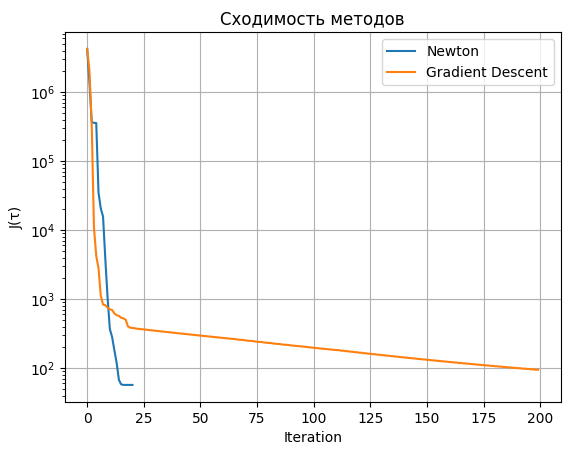

In [74]:
plt.figure()
plt.plot(hist_newton, label="Newton")
plt.plot(hist_gd, label="Gradient Descent")
plt.yscale("log")  # очень важно!
plt.xlabel("Iteration")
plt.ylabel("J(τ)")
plt.title("Сходимость методов")
plt.legend()
plt.grid()
plt.show()

In [75]:
print("Newton iterations:", len(hist_newton))
print("GD iterations:", len(hist_gd))

print("Newton final J:", hist_newton[-1])
print("GD final J:", hist_gd[-1])

Newton iterations: 21
GD iterations: 200
Newton final J: 56.95470228302928
GD final J: 94.62843948965221


### Вывод по заданию

В задаче оптимального торможения тележки было построено управление, параметризованное длительностями фаз движения, и введён штрафной функционал, позволяющий учитывать ограничения в рамках безусловной оптимизации. Метод Ньютона со стратегией Армихо эффективно минимизировал данный функционал, обеспечив быстрое получение решения, удовлетворяющего физическим требованиям задачи: тележка достигает целевой точки, практически останавливается в конце и соблюдает ограничения на управление. Построенные графики координаты, скорости и управления подтверждают корректность найденного решения и его физическую интерпретируемость.


## Общий вывод



В ходе лабораторной работы был изучен и реализован метод Ньютона для задач оптимизации. Были рассмотрены как теоретические аспекты метода, так и его практическое применение к различным функциям.

На тестовых функциях (включая квадратичные) метод Ньютона продемонстрировал ожидаемую квадратичную скорость сходимости вблизи минимума, что полностью согласуется с теоретическими результатами. При этом было показано, что использование стратегии выбора шага (в частности, условия Армихо) существенно повышает устойчивость метода и позволяет избежать расходимости.

В ходе экспериментов также было проведено сравнение метода Ньютона с градиентным спуском. Было установлено, что метод Ньютона достигает решения за значительно меньшее число итераций и обеспечивает более высокую точность, тогда как градиентный спуск сходится медленнее, особенно на заключительных этапах. Однако метод Ньютона требует вычисления матрицы Гессе и более чувствителен к выбору начального приближения.

В прикладной части работы была решена задача оптимального торможения тележки с учётом ограничений. Для её решения был введён штрафной функционал, позволяющий свести задачу с ограничениями к задаче безусловной оптимизации. Управление было параметризовано длительностями фаз движения, что позволило эффективно применять численные методы оптимизации.

Метод Ньютона со стратегией Армихо успешно применён для минимизации штрафного функционала. Полученное решение удовлетворяет физическим ограничениям задачи: тележка достигает целевой точки, имеет малую конечную скорость и соблюдает ограничения на управление. Построенные графики координаты, скорости и управления подтверждают корректность полученной траектории и её физическую интерпретируемость.

Таким образом, в работе была продемонстрирована высокая эффективность метода Ньютона для решения как абстрактных задач оптимизации, так и прикладных задач управления. Одновременно было показано, что для его успешного применения на практике необходимы дополнительные техники, такие как регуляризация, численное вычисление производных и стратегия выбора шага.
